In [1]:
import pandas as pd
import numpy as np

print("Environment Working")

Environment Working


In [2]:
matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [3]:
deliveries.head()


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [4]:
matches.shape


(756, 18)

In [5]:
deliveries.shape


(179078, 21)

In [6]:
matches.columns
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [7]:
matches.isnull().sum()


id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [8]:
matches = matches.dropna(subset=['winner'])


In [9]:
matches.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               0
win_by_runs          0
win_by_wickets       0
player_of_match      0
venue                0
umpire1              2
umpire2              2
umpire3            634
dtype: int64

In [10]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    170244
dismissal_kind      170244
fielder             172630
dtype: int64

In [11]:
matches['team1'] = matches['team1'].replace('Delhi Daredevils','Delhi Capitals')
matches['team2'] = matches['team2'].replace('Delhi Daredevils','Delhi Capitals')
matches['winner'] = matches['winner'].replace('Delhi Daredevils','Delhi Capitals')

matches['team1'] = matches['team1'].replace('Kings XI Punjab','Punjab Kings')
matches['team2'] = matches['team2'].replace('Kings XI Punjab','Punjab Kings')
matches['winner'] = matches['winner'].replace('Kings XI Punjab','Punjab Kings')

In [12]:
teams = [
    'Sunrisers Hyderabad',
    'Mumbai Indians',
    'Royal Challengers Bangalore',
    'Kolkata Knight Riders',
    'Punjab Kings',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Delhi Capitals'
]

In [13]:
matches = matches[matches['team1'].isin(teams)]
matches = matches[matches['team2'].isin(teams)]

In [14]:
matches = matches[matches['dl_applied'] == 0]

In [15]:
matches = matches[
    [
        'id',
        'city',
        'winner'
    ]
]

In [16]:
matches.head()

,id,city,winner
0,1,Hyderabad,Sunrisers Hyderabad
4,5,Bangalore,Royal Challengers Bangalore
6,7,Mumbai,Mumbai Indians
7,8,Indore,Punjab Kings
9,10,Mumbai,Mumbai Indians


In [17]:
total_score_df = deliveries.groupby(
    ['match_id','inning']
).sum()['total_runs'].reset_index()

In [18]:
total_score_df = total_score_df[
    total_score_df['inning'] == 1
]

In [19]:
match_df = matches.merge(
    total_score_df[['match_id','total_runs']],
    left_on='id',
    right_on='match_id'
)

In [20]:
match_df.head()

,id,city,winner,match_id,total_runs
0,1,Hyderabad,Sunrisers Hyderabad,1,207
1,5,Bangalore,Royal Challengers Bangalore,5,157
2,7,Mumbai,Mumbai Indians,7,178
3,8,Indore,Punjab Kings,8,148
4,10,Mumbai,Mumbai Indians,10,158


In [21]:
delivery_df = match_df.merge(
    deliveries,
    on='match_id'
)

In [22]:
delivery_df = delivery_df[
    delivery_df['inning_y'] == 2
]

KeyError: 'inning_y'

In [23]:
delivery_df = delivery_df[
    delivery_df['inning'] == 2
]

In [25]:
delivery_df['current_score'] = delivery_df.groupby(
    'match_id'
)['total_runs_y'].cumsum()

C:\Users\hp\AppData\Local\Temp\ipykernel_24860\1965647733.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['current_score'] = delivery_df.groupby(


In [26]:
delivery_df['runs_left'] = (
    delivery_df['total_runs_x']
    - delivery_df['current_score']
    + 1
)

C:\Users\hp\AppData\Local\Temp\ipykernel_24860\944935871.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['runs_left'] = (


In [27]:
delivery_df['balls_left'] = (
    126
    - (
        delivery_df['over']*6
        + delivery_df['ball']
    )
)

C:\Users\hp\AppData\Local\Temp\ipykernel_24860\3760549044.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['balls_left'] = (


In [28]:
delivery_df['player_dismissed'] = delivery_df[
    'player_dismissed'
].fillna("0")

delivery_df['player_dismissed'] = delivery_df[
    'player_dismissed'
].apply(lambda x:x if x=="0" else "1")

delivery_df['player_dismissed'] = delivery_df[
    'player_dismissed'
].astype('int')

wickets = delivery_df.groupby(
    'match_id'
)['player_dismissed'].cumsum().values

delivery_df['wickets_left'] = 10 - wickets

C:\Users\hp\AppData\Local\Temp\ipykernel_24860\2064756244.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['player_dismissed'] = delivery_df[
C:\Users\hp\AppData\Local\Temp\ipykernel_24860\2064756244.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['player_dismissed'] = delivery_df[
C:\Users\hp\AppData\Local\Temp\ipykernel_24860\2064756244.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

In [29]:
delivery_df['crr'] = (
    delivery_df['current_score']*6
) / (
    120 - delivery_df['balls_left']
)

C:\Users\hp\AppData\Local\Temp\ipykernel_24860\3881503671.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['crr'] = (


In [30]:
delivery_df['rrr'] = (
    delivery_df['runs_left']*6
) / delivery_df['balls_left']

C:\Users\hp\AppData\Local\Temp\ipykernel_24860\1879582031.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['rrr'] = (


In [31]:
def result(row):
    return 1 if row['batting_team'] == row['winner'] else 0

delivery_df['result'] = delivery_df.apply(
    result,
    axis=1
)

C:\Users\hp\AppData\Local\Temp\ipykernel_24860\850893221.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['result'] = delivery_df.apply(


In [32]:
final_df = delivery_df[
    [
        'batting_team',
        'bowling_team',
        'city',
        'runs_left',
        'balls_left',
        'wickets_left',
        'total_runs_x',
        'crr',
        'rrr',
        'result'
    ]
]

In [33]:
final_df = final_df.dropna()

In [34]:
final_df.head()

,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,total_runs_x,crr,rrr,result
125,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,207,119,10,207,6.0,10.436975,0
126,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,207,118,10,207,3.0,10.525424,0
127,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,207,117,10,207,2.0,10.615385,0
128,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,205,116,10,207,4.5,10.603448,0
129,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,201,115,10,207,8.4,10.486957,0


In [35]:
final_df.shape

(63328, 10)

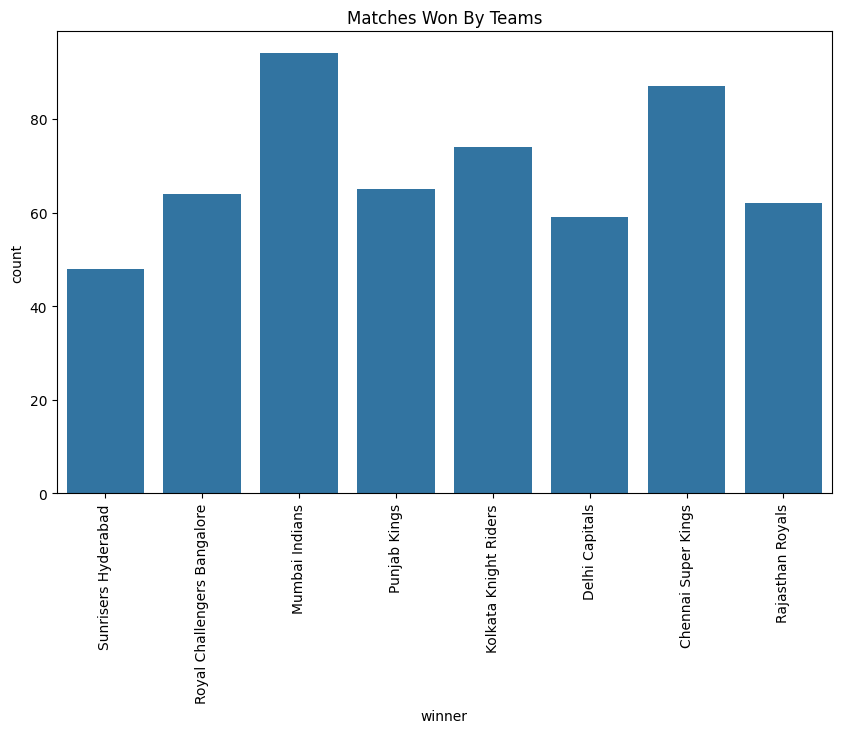

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.countplot(x=matches['winner'])

plt.xticks(rotation=90)

plt.title("Matches Won By Teams")

plt.show()

In [36]:
sns.countplot(x=matches['toss_decision'])

plt.title("Toss Decision Distribution")

plt.show()

KeyError: 'toss_decision'

In [37]:
plt.figure(figsize=(10,5))

sns.histplot(matches['win_by_runs'], bins=30)

plt.title("Win By Runs Distribution")

plt.show()

KeyError: 'win_by_runs'

<Figure size 1000x500 with 0 Axes>

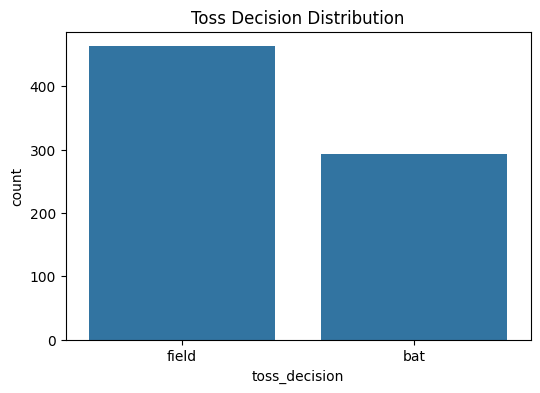

In [38]:
matches_full = pd.read_csv('../data/matches.csv')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=matches_full['toss_decision'])

plt.title("Toss Decision Distribution")

plt.show()

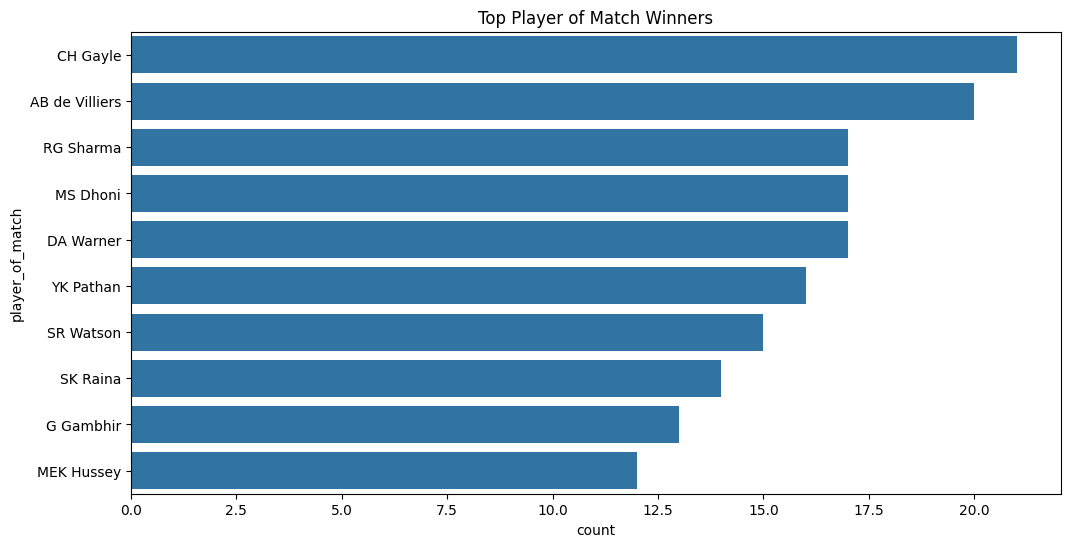

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
matches_full = pd.read_csv('../data/matches.csv')

# Create figure
plt.figure(figsize=(12,6))

# Plot graph
sns.countplot(
    y=matches_full['player_of_match'],
    order=matches_full['player_of_match'].value_counts().iloc[:10].index
)

# Add title
plt.title("Top Player of Match Winners")

# Show graph
plt.show()

3. Top IPL Venues

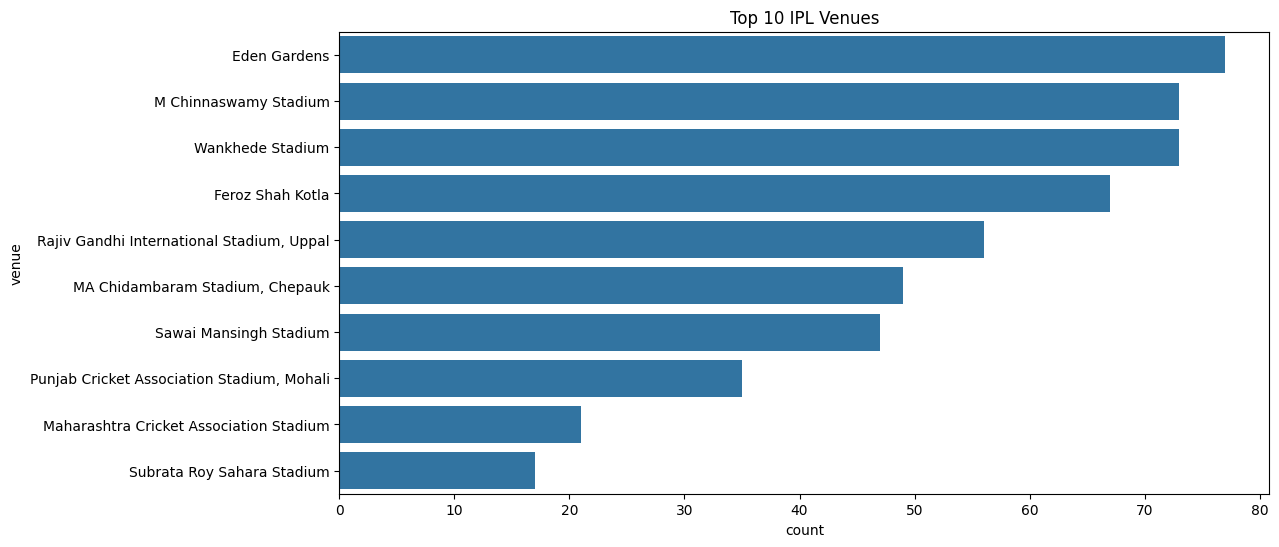

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches_full = pd.read_csv('../data/matches.csv')

plt.figure(figsize=(12,6))

sns.countplot(
    y=matches_full['venue'],
    order=matches_full['venue'].value_counts().iloc[:10].index
)

plt.title("Top 10 IPL Venues")

plt.show()

4. Win By Runs Distribution

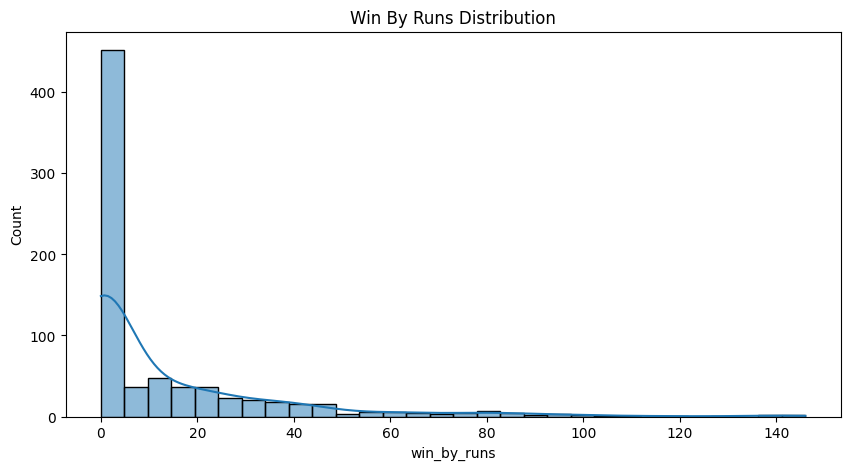

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches_full = pd.read_csv('../data/matches.csv')

plt.figure(figsize=(10,5))

sns.histplot(
    matches_full['win_by_runs'],
    bins=30,
    kde=True
)

plt.title("Win By Runs Distribution")

plt.show()

6. Top Toss Winners

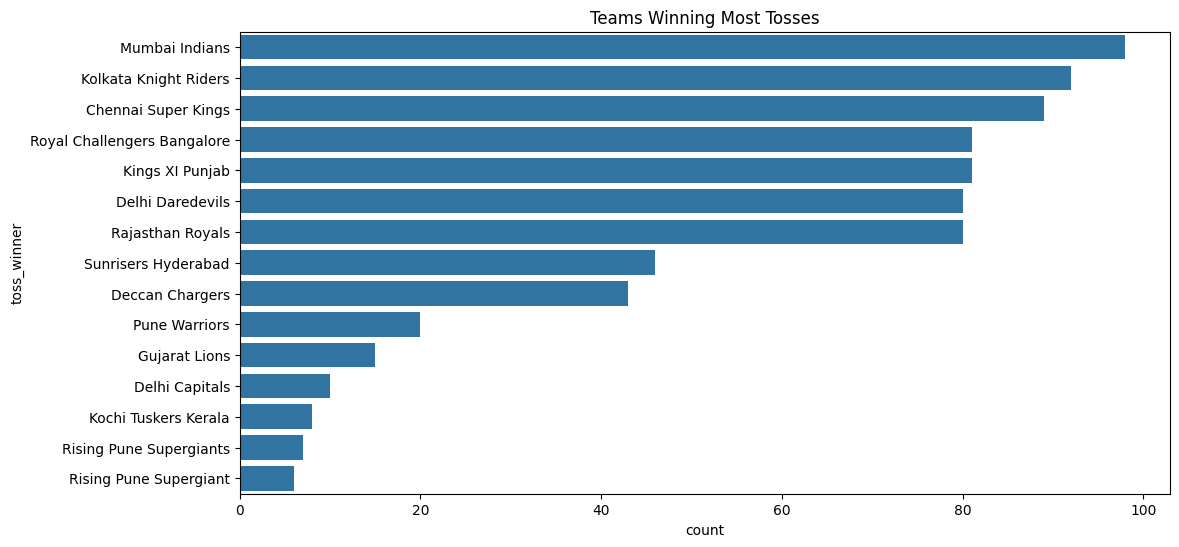

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches_full = pd.read_csv('../data/matches.csv')

plt.figure(figsize=(12,6))

sns.countplot(
    y=matches_full['toss_winner'],
    order=matches_full['toss_winner'].value_counts().index
)

plt.title("Teams Winning Most Tosses")

plt.show()

In [43]:
X = final_df.drop('result', axis=1)
y = final_df['result']

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [47]:
trf = ColumnTransformer([
    (
        'trf',
        OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
        ['batting_team','bowling_team','city']
    )
], remainder='passthrough')

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
   
}

c:\Users\hp\Desktop\IplWinPredictor\venv\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8592475247524752
Decision Tree Accuracy: 0.9942178217821782
Random Forest Accuracy: 0.9991287128712871
Naive Bayes Accuracy: 0.716990099009901

MODEL COMPARISON RESULTS

Logistic Regression: 0.8592475247524752
Decision Tree: 0.9942178217821782
Random Forest: 0.9991287128712871
Naive Bayes: 0.716990099009901


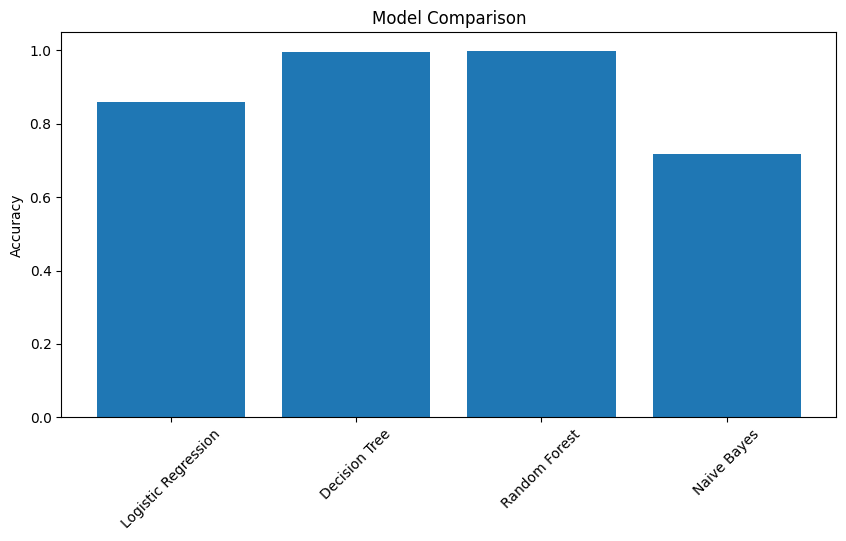

In [37]:
# ============================================
# IPL WIN PREDICTION - MODEL TRAINING
# ============================================

# =========================
# IMPORT LIBRARIES
# =========================

import numpy as np
import pandas as pd

# =========================
# CLEAN DATA
# =========================

# Remove infinity values
final_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove null values
final_df.dropna(inplace=True)

# =========================
# FEATURES & TARGET
# =========================

X = final_df.drop('result', axis=1)

y = final_df['result']

# =========================
# TRAIN TEST SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# PREPROCESSING
# =========================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

trf = ColumnTransformer([
    (
        'trf',
        OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore'
        ),
        ['batting_team', 'bowling_team', 'city']
    )
], remainder='passthrough')

# =========================
# IMPORT MODELS
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# =========================
# MODEL COMPARISON
# =========================

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB()
}

# =========================
# TRAIN & EVALUATE MODELS
# =========================

from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():

    pipe = Pipeline([
        ('step1', trf),
        ('step2', model)
    ])

    # Train model
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Store result
    results[name] = accuracy

    print(f"{name} Accuracy: {accuracy}")

# =========================
# SHOW RESULTS
# =========================

print("\n=========================")
print("MODEL COMPARISON RESULTS")
print("=========================\n")

for model_name, score in results.items():
    print(f"{model_name}: {score}")

# =========================
# VISUALIZE RESULTS
# =========================

import matplotlib.pyplot as plt

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,5))

plt.bar(model_names, accuracies)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()



In [38]:
from xgboost import XGBClassifier

xgb_pipe = Pipeline([
    ('step1', trf),
    ('step2', XGBClassifier(
        n_estimators=50,
        max_depth=5,
        learning_rate=0.1,
        eval_metric='logloss',
        random_state=42
    ))
])

# Train XGBoost
xgb_pipe.fit(X_train, y_train)

# Predict
xgb_pred = xgb_pipe.predict(X_test)

# Accuracy
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("\n=========================")
print("XGBOOST ACCURACY")
print("=========================\n")



XGBOOST ACCURACY



In [39]:
print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.8879207920792079


In [40]:
xgb_pipe

c:\Users\hp\Desktop\IplWinPredictor\venv\lib\site-packages\sklearn\compose\_column_transformer.py:1624: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'city'])])),
                ('step2',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=50, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [41]:
import pickle

pickle.dump(xgb_pipe, open('../pipe.pkl', 'wb'))